# Bridge: Real LOB Data → Contrastive Training Pipeline

**Goal**: Load LOBSTER CSV data, replay through JAX order book, extract `(10, 3, 2)` normalized snapshots,
then feed them into the contrastive training cells from `vision_agent_playground.ipynb`.

**Pipeline**:
1. Load cached `.npz` (or raw CSVs via `LoadLOBSTER_resample`)
2. For each window: init OB → replay messages → snapshot at each step
3. `get_vision_L2_state` → raw `(10, 2, 2)` → `normalize_vision_obs` → `(10, 3, 2)`
4. Collect mid_prices alongside snapshots
5. Plug into pair builder + contrastive training from the playground notebook

In [21]:
# ============================================================
# Cell 2: Imports & Setup
# ============================================================
import sys, os
import jax
import jax.numpy as jnp
import jax.random as jrandom
import numpy as np
from functools import partial

jax.config.update("jax_enable_x64", False)

##nhớ chỉnh lúc train nhe

jax.config.update("jax_platform_name", "cpu")  # Force CPU — avoids CUDA errors in WSL2

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.dirname("__file__"))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import project modules
import gymnax_exchange.jaxob.JaxOrderBookArrays as job
from gymnax_exchange.jaxob.jaxob_config import (
    JAXLOB_Configuration, World_EnvironmentConfig
)
from gymnax_exchange.jaxlobster.lobster_loader import LoadLOBSTER_resample

print(f"JAX backend: {jax.default_backend()}")
print(f"Devices: {jax.devices()}")

JAX backend: cpu
Devices: [CpuDevice(id=0)]


In [22]:
# ============================================================
# Cell 3: Load LOBSTER Data
# ============================================================
# Point these at your actual data location.
# The loader expects: datapath/AMZN/2012-06-21/*.csv
#
# If a cached .npz already exists in saved_npz/, it loads instantly.

DATAPATH = PROJECT_ROOT          # folder containing AMZN/2012-06-21/
ATPATH   = PROJECT_ROOT          # project root (for saved_npz/ cache)
STOCK    = "AMZN"
PERIOD   = "2012-06-21"          # subfolder name under AMZN/

loader = LoadLOBSTER_resample(
    datapath=DATAPATH,
    atpath=ATPATH,
    n_Levels=10,
    type_="fixed_time",
    window_length=1800,           # 30-min episodes
    window_resolution=60,         # new window every 60s
    n_data_msg_per_step=100,      # 100 messages per step
    stock=STOCK,
    time_period=PERIOD,
)

msgs, starts, ends, obs, max_msgs_arr = loader.run_loading()

print(f"Messages shape:       {msgs.shape}")
print(f"Window starts:        {starts.shape}")
print(f"Window ends:          {ends.shape}")
print(f"Initial OB states:    {obs.shape}")              # (N_windows, 40)
print(f"Max msgs per window:  {max_msgs_arr.shape}")
print(f"Number of windows:    {len(starts)}")
print(f"Sample OB state [0]:  {obs[0][:8]}  (ask1_p, ask1_q, bid1_p, bid1_q, ...)")

self.datapath /mnt/c/Users/doanduchieu001/Documents/GitHub/ViT-MARL/AMZN/2012-06-21/
found 1 message files
found 1 book files
Loading cached arrays from /mnt/c/Users/doanduchieu001/Documents/GitHub/ViT-MARL/saved_npz/lobster_AMZN_2012-06-21_10_fixed_time_1800_60_100_34200_57600.npz
Messages shape:       (267328, 8)
Window starts:        (390,)
Window ends:          (390,)
Initial OB states:    (390, 40)
Max msgs per window:  (390,)
Number of windows:    390
Sample OB state [0]:  [2239500     100 2231800     100 2239900     100 2230700     200]  (ask1_p, ask1_q, bid1_p, bid1_q, ...)


In [23]:
# ============================================================
# Cell 4: Standalone normalize_vision_obs (no class dependency)
# ============================================================
# Extracted from ExecutionAgent.normalize_vision_obs in vision_env.py
# so we can use it in this notebook without instantiating the full env.

def normalize_vision_obs(raw_tensor: jnp.ndarray,
                         mid_price: float,
                         tick_size: float = 100.0) -> jnp.ndarray:
    """Convert raw (10, 2, 2) vision tensor to normalized (10, 3, 2).
    
    Mirrors ExecutionAgent.normalize_vision_obs from vision_env.py.
    
    Input raw_tensor shape:  (n_levels, 2, 2)  →  [Price, Vol] x [Ask, Bid]
    Output shape:            (n_levels, 3, 2)  →  [Gap, LogVol, CumVol] x [Ask, Bid]
    """
    prices_ask = raw_tensor[:, 0, 0]  # Ask prices
    vols_ask   = raw_tensor[:, 1, 0]  # Ask volumes
    prices_bid = raw_tensor[:, 0, 1]  # Bid prices
    vols_bid   = raw_tensor[:, 1, 1]  # Bid volumes
    
    # --- ASK SIDE ---
    valid_ask = prices_ask != -1
    gap_ask = jnp.where(valid_ask, (prices_ask - mid_price) / tick_size, 0)
    clean_vol_ask = jnp.where(valid_ask, vols_ask, 0)
    log_vol_ask = jnp.log1p(clean_vol_ask)
    raw_cum_ask = jnp.cumsum(clean_vol_ask)
    cum_vol_ask = jnp.log1p(jnp.where(valid_ask, raw_cum_ask, 0))
    feat_ask = jnp.stack([gap_ask, log_vol_ask, cum_vol_ask], axis=1)   # (10, 3)
    
    # --- BID SIDE ---
    valid_bid = prices_bid != -1
    gap_bid = jnp.where(valid_bid, (mid_price - prices_bid) / tick_size, 0)
    clean_vol_bid = jnp.where(valid_bid, vols_bid, 0)
    log_vol_bid = jnp.log1p(clean_vol_bid)
    raw_cum_bid = jnp.cumsum(clean_vol_bid)
    cum_vol_bid = jnp.log1p(jnp.where(valid_bid, raw_cum_bid, 0))
    feat_bid = jnp.stack([gap_bid, log_vol_bid, cum_vol_bid], axis=1)   # (10, 3)
    
    # --- STACK ---
    return jnp.stack([feat_ask, feat_bid], axis=-1)  # (10, 3, 2)


print("normalize_vision_obs defined ✓")
print("Signature: raw (10,2,2) + mid_price → normalized (10,3,2)")

normalize_vision_obs defined ✓
Signature: raw (10,2,2) + mid_price → normalized (10,3,2)


In [24]:
# ============================================================
# Cell 5: Extract Snapshots from Real Data
# ============================================================
# For each window: init OB from L2 → replay messages → snapshot at each step
# → normalize → collect.
#
# This produces the REAL (10, 3, 2) tensors + mid_prices that
# replace the synthetic data in the playground notebook.

# Config for OB replay
# NOTE: tick_size, nOrdersPerSide, etc. are class-level attributes (no type
# annotation in the dataclass), so they can't be passed to __init__.
# The defaults (tick_size=100, nOrders=100, nTrades=100) are already correct.
world_cfg = World_EnvironmentConfig()

N_LEVELS = 10
MSGS_PER_STEP = 100          # same as n_data_msg_per_step
MAX_WINDOWS = min(1, len(starts))  # how many windows to process (tune for speed)
MAX_STEPS_PER_WINDOW = 50    # cap steps per window (tune for memory)

all_snapshots = []
all_mid_prices = []

rng_key = jrandom.PRNGKey(0)

for w in range(MAX_WINDOWS):
    # --- Init OB from L2 state ---
    book_l2 = jnp.array(obs[w])                      # (40,) = 10 levels * 2 sides * 2 (price, qty)
    first_msg_idx = int(starts[w])
    time_init = jnp.array(msgs[first_msg_idx, -2:])   # [seconds, nanoseconds]
    
    init_orders = job.init_msgs_from_l2(world_cfg, book_l2, time_init)
    asks_raw = job.init_orderside(world_cfg.nOrders)
    bids_raw = job.init_orderside(world_cfg.nOrders)
    trades_init = (jnp.ones((world_cfg.nTrades, 8)) * -1).astype(jnp.int32)
    
    rng_key, subkey = jrandom.split(rng_key)
    book_state = job.scan_through_entire_array(
        world_cfg, subkey, init_orders, (asks_raw, bids_raw, trades_init)
    )
    asks, bids, trades = book_state
    
    # --- Replay messages in chunks, snapshot after each ---
    n_total_msgs = int(max_msgs_arr[w])
    n_steps = min(n_total_msgs // MSGS_PER_STEP, MAX_STEPS_PER_WINDOW)
    
    for step in range(n_steps):
        msg_start = first_msg_idx + step * MSGS_PER_STEP
        msg_end = msg_start + MSGS_PER_STEP
        step_msgs = jnp.array(msgs[msg_start:msg_end])
        
        rng_key, subkey = jrandom.split(rng_key)
        book_state = job.scan_through_entire_array(
            world_cfg, subkey, step_msgs, (asks, bids, trades)
        )
        asks, bids, trades = book_state
        
        # --- Snapshot ---
        raw_vision = job.get_vision_L2_state(asks, bids, N_LEVELS, world_cfg)  # (10, 2, 2)
        
        # Compute mid price from best bid/ask
        best_ask, best_bid = job.get_best_bid_and_ask(world_cfg, asks, bids)
        mid_price = (best_ask + best_bid) / 2.0  # Keep as JAX scalar
        
        # Normalize
        norm_vision = normalize_vision_obs(raw_vision, mid_price, world_cfg.tick_size)  # (10, 3, 2)
        
        all_snapshots.append(norm_vision)
        all_mid_prices.append(mid_price)  # Store JAX scalar, convert later
    
    if (w + 1) % 5 == 0:
        print(f"Window {w+1}/{MAX_WINDOWS} done — {len(all_snapshots)} snapshots so far")

# Stack into arrays
snapshots = jnp.stack(all_snapshots)      # (N, 10, 3, 2)
mid_prices = jnp.array(all_mid_prices)    # (N,) - Keep as JAX, it works fine


# Convert to numpy first for easier printing
#mid_prices_np = np.array(mid_prices)





In [25]:
print(f"\n{'='*50}")
print(f"Total snapshots collected: {snapshots.shape}")
print(f"mid_prices type: {type(mid_prices)}")
print(f"mid_prices shape: {mid_prices.shape}")
try:
    mp_np = np.array(mid_prices)
    print(f"Converted to numpy successfully: {type(mp_np)}")
except Exception as e:
    print(f"Error converting to numpy: {e}")


Total snapshots collected: (50, 10, 3, 2)
mid_prices type: <class 'jaxlib._jax.ArrayImpl'>
mid_prices shape: (50,)
Converted to numpy successfully: <class 'numpy.ndarray'>


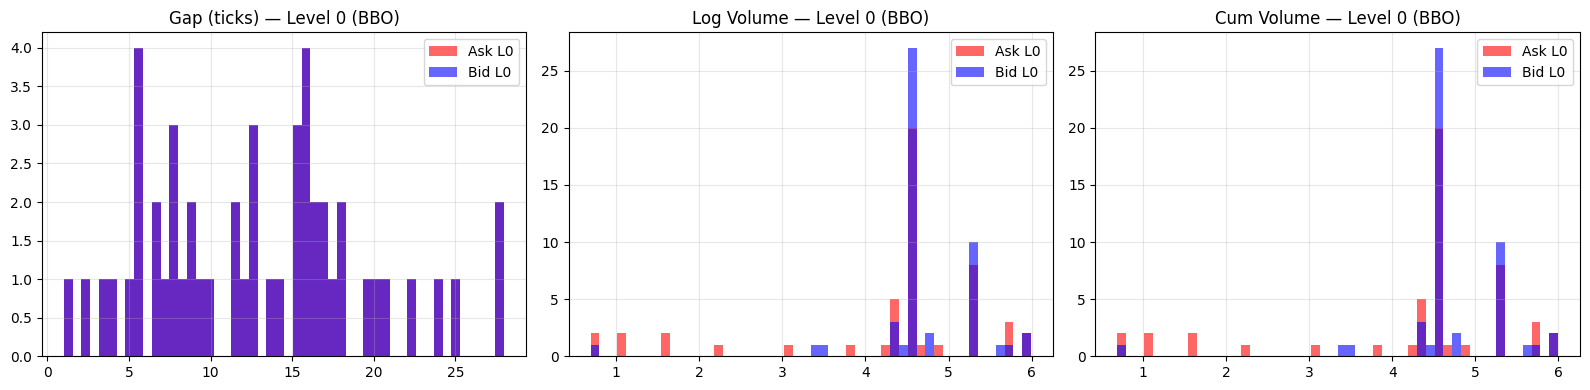

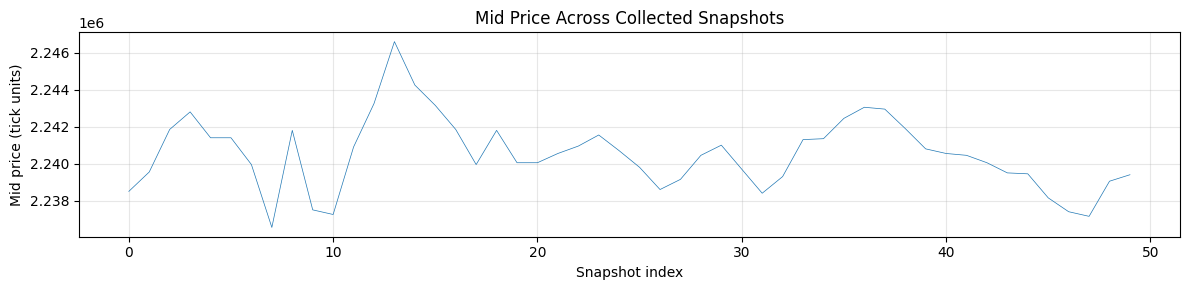


Feature statistics (mean ± std across all snapshots):
  Gap (ticks)      Ask:    39.51 ±  36.29   Bid:    44.50 ±  35.86
  Log Volume       Ask:     4.55 ±   1.09   Bid:     4.42 ±   1.10
  Cum Volume       Ask:     6.24 ±   1.07   Bid:     6.22 ±   0.87


In [26]:
# ============================================================
# Cell 6: Inspect the Real Snapshots
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Feature names: [Gap, LogVol, CumVol] x [Ask, Bid]
feat_names = ['Gap (ticks)', 'Log Volume', 'Cum Volume']

for f_idx in range(3):
    ask_vals = snapshots[:, :, f_idx, 0]  # (N, 10) — ask side
    bid_vals = snapshots[:, :, f_idx, 1]  # (N, 10) — bid side
    
    # Plot distribution of feature across all snapshots, level 0 (BBO)
    axes[f_idx].hist(np.array(ask_vals[:, 0]), bins=50, alpha=0.6, label='Ask L0', color='red')
    axes[f_idx].hist(np.array(bid_vals[:, 0]), bins=50, alpha=0.6, label='Bid L0', color='blue')
    axes[f_idx].set_title(f'{feat_names[f_idx]} — Level 0 (BBO)')
    axes[f_idx].legend()
    axes[f_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mid-price time series
fig2, ax2 = plt.subplots(figsize=(12, 3))
ax2.plot(np.array(mid_prices), linewidth=0.5)
ax2.set_xlabel('Snapshot index')
ax2.set_ylabel('Mid price (tick units)')
ax2.set_title('Mid Price Across Collected Snapshots')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Stats
print(f"\nFeature statistics (mean ± std across all snapshots):")
for f_idx, name in enumerate(feat_names):
    ask_mean = float(snapshots[:, :, f_idx, 0].mean())
    ask_std  = float(snapshots[:, :, f_idx, 0].std())
    bid_mean = float(snapshots[:, :, f_idx, 1].mean())
    bid_std  = float(snapshots[:, :, f_idx, 1].std())
    print(f"  {name:15s}  Ask: {ask_mean:8.2f} ± {ask_std:6.2f}   Bid: {bid_mean:8.2f} ± {bid_std:6.2f}")

In [27]:
# ============================================================
# Cell 7: Build Pairs from Real Data
# ============================================================
# Same pair builder as playground Cell 7, but on real snapshots.

from typing import Tuple

def build_pairs_midprice(
    snapshots: jnp.ndarray,   # (N, 10, 3, 2)
    mid_prices: jnp.ndarray,  # (N,)
    threshold: float = 0.02,
    max_pairs: int = 512,
    rng: jax.Array = jrandom.PRNGKey(0),
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """Build positive pairs: snapshots with similar mid-prices."""
    N = snapshots.shape[0]
    price_diffs = jnp.abs(mid_prices[:, None] - mid_prices[None, :])
    rel_diffs = price_diffs / jnp.maximum(mid_prices[:, None], 1e-8)
    similar_mask = (rel_diffs < threshold) & (jnp.eye(N) == 0)
    n_valid = similar_mask.sum(axis=1)
    has_partner = n_valid > 0
    
    rng1, _ = jrandom.split(rng)
    gumbel_noise = jrandom.gumbel(rng1, (N, N))
    masked_scores = jnp.where(similar_mask, gumbel_noise, -jnp.inf)
    partner_indices = jnp.argmax(masked_scores, axis=1)
    
    obs_a_all = snapshots
    obs_b_all = snapshots[partner_indices]
    valid_indices = jnp.where(has_partner, size=max_pairs, fill_value=0)[0]
    
    return obs_a_all[valid_indices], obs_b_all[valid_indices]


# Build pairs
rng_pair = jrandom.PRNGKey(123)
MAX_PAIRS = min(512, snapshots.shape[0])
obs_a, obs_b = build_pairs_midprice(
    snapshots, mid_prices,
    threshold=0.02,
    max_pairs=MAX_PAIRS,
    rng=rng_pair,
)
print(f"Pair shapes: obs_a={obs_a.shape}, obs_b={obs_b.shape}")
print(f"Pairs built from REAL data ✓")

Pair shapes: obs_a=(50, 10, 3, 2), obs_b=(50, 10, 3, 2)
Pairs built from REAL data ✓


In [28]:
# ============================================================
# Cell 8: CNN Encoder + Loss Functions (from playground)
# ============================================================
from flax import linen as nn
import optax
from typing import Dict, NamedTuple


class VisionCNN(nn.Module):
    embed_dim: int = 32
    
    @nn.compact
    def __call__(self, x, *, train: bool = False):
        x = jnp.asarray(x, dtype=jnp.float32)
        squeeze = False
        if x.ndim == 3:
            x = x[None, ...]
            squeeze = True
        B = x.shape[0]
        x = x.reshape(B, 10, -1)       # (B, 10, 6)
        x = nn.Conv(features=32, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(features=64, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = jnp.mean(x, axis=1)        # GAP → (B, 64)
        x = nn.Dense(self.embed_dim)(x) # (B, embed_dim)
        if squeeze:
            x = x.squeeze(0)
        return x


def _l2_normalize(x, eps=1e-8):
    return x / jnp.maximum(jnp.linalg.norm(x, axis=-1, keepdims=True), eps)


def contrastive_loss_global(params, model, obs_a, obs_b, temperature=0.1):
    z_a = _l2_normalize(model.apply(params, obs_a, train=True))
    z_b = _l2_normalize(model.apply(params, obs_b, train=True))
    logits = (z_a @ z_b.T) / temperature
    labels = jnp.arange(logits.shape[0])
    loss_a = -jnp.take_along_axis(
        jax.nn.log_softmax(logits, axis=-1), labels[:, None], axis=-1
    ).squeeze(-1).mean()
    loss_b = -jnp.take_along_axis(
        jax.nn.log_softmax(logits.T, axis=-1), labels[:, None], axis=-1
    ).squeeze(-1).mean()
    return 0.5 * (loss_a + loss_b)


print("VisionCNN + contrastive_loss_global defined ✓")

VisionCNN + contrastive_loss_global defined ✓


In [29]:
# ============================================================
# Cell 9: Training on Real Data
# ============================================================

class TrainState(NamedTuple):
    params: Dict
    opt_state: optax.OptState
    step: int


# --- Hyperparameters (tweak these!) ---
EMBED_DIM = 32
LR = 3e-4
TEMPERATURE = 0.1
NUM_EPOCHS = 50
BATCH_SIZE = 32

# --- Init model ---
encoder = VisionCNN(embed_dim=EMBED_DIM)
rng_init = jrandom.PRNGKey(42)
dummy = jnp.ones((1, 10, 3, 2))
variables = encoder.init(rng_init, dummy)
params = variables['params'] if 'params' in variables else variables

optimizer = optax.adam(LR)
opt_state = optimizer.init(params)
step = 0

n_pairs = obs_a.shape[0]
print(f"Training on {n_pairs} real LOB pairs")
print(f"Encoder: VisionCNN(embed_dim={EMBED_DIM})")
print(f"Hyperparams: lr={LR}, temp={TEMPERATURE}, epochs={NUM_EPOCHS}, batch={BATCH_SIZE}")


# --- JIT-compiled train step ---
@jax.jit
def train_step(params, opt_state, step, batch_a, batch_b):
    def loss_fn(p):
        return contrastive_loss_global({'params': p}, encoder, batch_a, batch_b, TEMPERATURE)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, step + 1, loss


# --- Training loop ---
losses = []
for epoch in range(NUM_EPOCHS):
    perm = jrandom.permutation(jrandom.PRNGKey(42 + epoch), n_pairs)
    epoch_a = obs_a[perm]
    epoch_b = obs_b[perm]
    
    n_batches = n_pairs // BATCH_SIZE
    epoch_loss = 0.0
    for b in range(n_batches):
        s, e = b * BATCH_SIZE, (b + 1) * BATCH_SIZE
        params, opt_state, step, loss = train_step(
            params, opt_state, step, epoch_a[s:e], epoch_b[s:e]
        )
        epoch_loss += float(loss)
    
    avg_loss = epoch_loss / max(n_batches, 1)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}")

print(f"\nTraining complete! Final loss: {losses[-1]:.4f}")
final_params = params

Training on 50 real LOB pairs
Encoder: VisionCNN(embed_dim=32)
Hyperparams: lr=0.0003, temp=0.1, epochs=50, batch=32
Epoch   1/50 | Loss: 3.5132
Epoch  10/50 | Loss: 3.4964
Epoch  20/50 | Loss: 3.4872
Epoch  30/50 | Loss: 3.4701
Epoch  40/50 | Loss: 3.4698
Epoch  50/50 | Loss: 3.4657

Training complete! Final loss: 3.4657


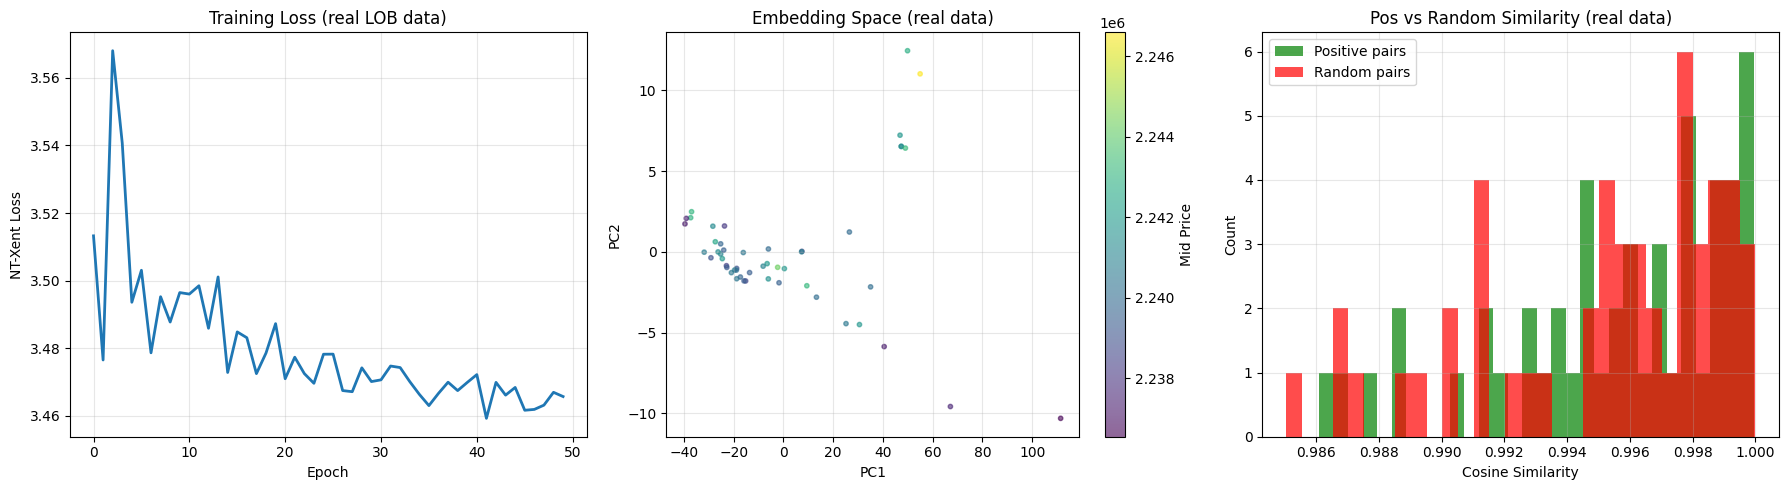


Cosine Similarity (real data):
  Positive: mean=0.996, std=0.004
  Random:   mean=0.995, std=0.004
  Separation: 0.000
  PCA variance: [0.96831787 0.01424183]


In [30]:
# ============================================================
# Cell 10: Visualization & Evaluation (on real data)
# ============================================================
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Loss curve ---
axes[0].plot(losses, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NT-Xent Loss')
axes[0].set_title('Training Loss (real LOB data)')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: PCA of embeddings colored by mid-price ---
n_vis = min(500, snapshots.shape[0])
all_emb = encoder.apply({'params': final_params}, snapshots[:n_vis])
emb_np = np.array(all_emb)
mp_np = np.array(mid_prices[:n_vis])

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_np)

sc = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=mp_np, cmap='viridis', alpha=0.6, s=10)
plt.colorbar(sc, ax=axes[1], label='Mid Price')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Embedding Space (real data)')
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Cosine similarity — positive vs random ---
n_eval = min(200, obs_a.shape[0])
z_a = _l2_normalize(encoder.apply({'params': final_params}, obs_a[:n_eval]))
z_b = _l2_normalize(encoder.apply({'params': final_params}, obs_b[:n_eval]))
cos_pos = jnp.sum(z_a * z_b, axis=-1)

rand_idx = jrandom.permutation(jrandom.PRNGKey(999), n_eval)
cos_neg = jnp.sum(z_a * _l2_normalize(encoder.apply({'params': final_params}, obs_b[:n_eval][rand_idx])), axis=-1)

axes[2].hist(np.array(cos_pos), bins=30, alpha=0.7, label='Positive pairs', color='green')
axes[2].hist(np.array(cos_neg), bins=30, alpha=0.7, label='Random pairs', color='red')
axes[2].set_xlabel('Cosine Similarity')
axes[2].set_ylabel('Count')
axes[2].set_title('Pos vs Random Similarity (real data)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCosine Similarity (real data):")
print(f"  Positive: mean={float(cos_pos.mean()):.3f}, std={float(cos_pos.std()):.3f}")
print(f"  Random:   mean={float(cos_neg.mean()):.3f}, std={float(cos_neg.std()):.3f}")
print(f"  Separation: {float(cos_pos.mean() - cos_neg.mean()):.3f}")
print(f"  PCA variance: {pca.explained_variance_ratio_}")

## Knobs to Tweak

| Parameter | Cell | Effect |
|---|---|---|
| `MAX_WINDOWS` | Cell 5 | More windows → more snapshots (slower extraction) |
| `MAX_STEPS_PER_WINDOW` | Cell 5 | More steps per window → denser sampling |
| `threshold` | Cell 7 | Strictness of "similar" pairs (0.01 = 1%, 0.05 = 5%) |
| `MAX_PAIRS` | Cell 7 | Training set size |
| `EMBED_DIM` | Cell 9 | Embedding dimensionality |
| `LR` | Cell 9 | Learning rate |
| `TEMPERATURE` | Cell 9 | NT-Xent sharpness (lower = stricter) |
| `NUM_EPOCHS` | Cell 9 | Training duration |
| `BATCH_SIZE` | Cell 9 | Mini-batch size |

### If training looks bad:
- **Loss stays flat**: increase `threshold` (more lenient pairing) or decrease `TEMPERATURE`
- **Loss oscillates**: decrease `LR`
- **Embeddings don't cluster by price**: need more data (`MAX_WINDOWS`) or stricter pairs (`threshold`)
- **Too few pairs**: increase `threshold` or `MAX_WINDOWS`